In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
for dirpath, dirnames, filenames in os.walk(r"C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 1 directories and 3 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN'.
There are 2 directories and 0 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset'.
There are 2 directories and 0 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset\train'.
There are 0 directories and 250 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset\train\angry'.
There are 0 directories and 1652 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset\train\happy'.
There are 2 directories and 0 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset\validation'.
There are 0 directories and 703 images in 'C:\Users\samriddhiashoksingh\OneDrive\Desktop\PGA38\Machine Learning\Dataset CNN\Dataset\validation\angry'.
There are 0 directo

In [4]:
# Directory path
base_dir = r"D:\Backup 14.03.2021\Desktop\Imarticus Post\Online PGA 23\DL & AI\Project on CNN\DATASET"
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Training Directory Path

train_buildings_dir = os.path.join(train_dir, 'buildings')
train_forest_dir = os.path.join(train_dir, 'forest')
train_sea_dir = os.path.join(train_dir, 'sea')

In [4]:
ncols = 4
nrows = 1
num_images = 4

def view_random_image(target_dir):
    fig = plt.gcf()
    fig.set_size_inches(ncols * 4, nrows * 4)

    random_image = random.sample(os.listdir(target_dir), num_images)

    for i, img_path in enumerate(random_image):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.axis('off')

        img = mpimg.imread(os.path.join(target_dir, img_path))
        plt.imshow(img)
        plt.title(os.path.basename(target_dir))

    plt.show()

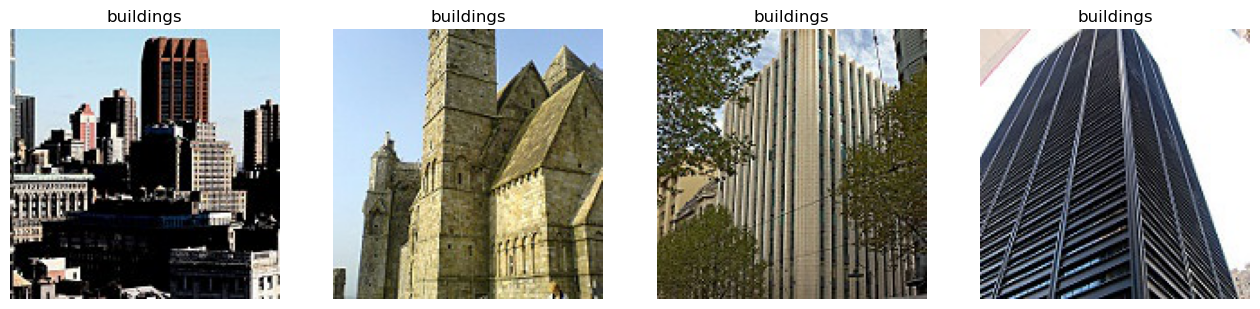

In [5]:
view_random_image(train_buildings_dir)

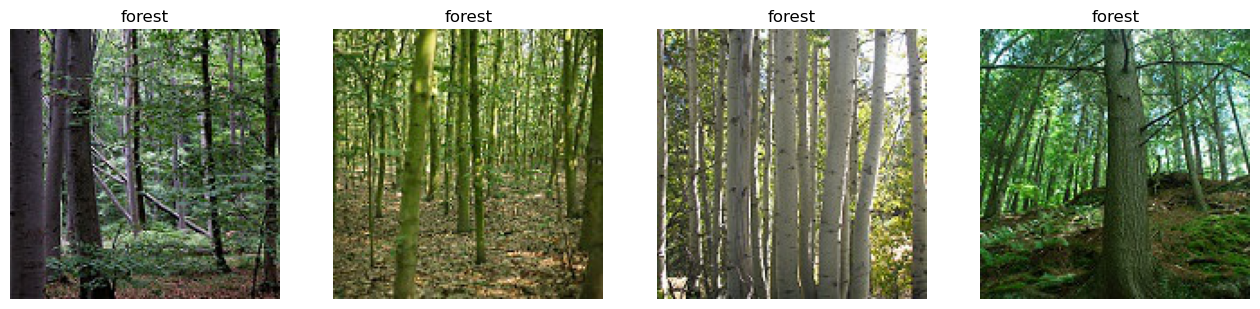

In [6]:
view_random_image(train_forest_dir)

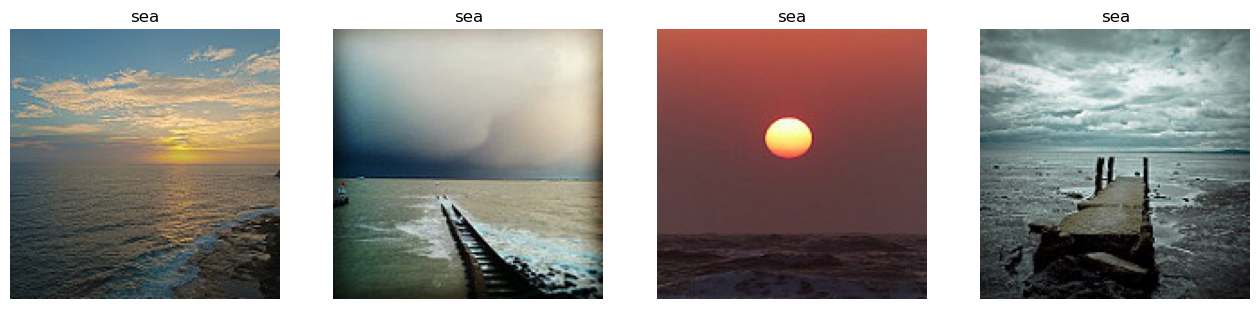

In [7]:
view_random_image(train_sea_dir)

In [8]:
#Image Data Preprocessing

train_datagen = ImageDataGenerator(rescale=1/255.,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,        # shear_range specifies the angle of the slant in degrees. It is a used for image augmentation  
                                   zoom_range=0.2,
                                   horizontal_flip=True)

validation_datagen = ImageDataGenerator(rescale=1/255.)

In [9]:
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    batch_size=32,
                                                    class_mode='categorical',
                                                    target_size=(150, 150))

validation_generator = train_datagen.flow_from_directory(test_dir,
                                                         batch_size=32,
                                                         class_mode='categorical',
                                                         target_size=(150, 150))

Found 5387 images belonging to 3 classes.
Found 1421 images belonging to 3 classes.


In [10]:
#Building Model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    
    tf.keras.layers.Dense(3, activation='softmax')
])

C:\Users\Arun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss')

history = model.fit(train_generator,
                    epochs=30,
                    validation_data=validation_generator,
                    validation_steps=64,
                    callbacks=[early_stopping])

Epoch 1/30


C:\Users\Arun\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


169/169 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.6503 - loss: 0.7451 - val_accuracy: 0.8466 - val_loss: 0.4069
Epoch 2/30


C:\Users\Arun\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


169/169 ━━━━━━━━━━━━━━━━━━━━ 105s 613ms/step - accuracy: 0.8529 - loss: 0.3786 - val_accuracy: 0.8790 - val_loss: 0.3408
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 118s 693ms/step - accuracy: 0.8762 - loss: 0.3285 - val_accuracy: 0.8790 - val_loss: 0.3036
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 126s 739ms/step - accuracy: 0.8936 - loss: 0.2757 - val_accuracy: 0.8705 - val_loss: 0.3150
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 122s 716ms/step - accuracy: 0.8952 - loss: 0.2870 - val_accuracy: 0.9198 - val_loss: 0.2327
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 126s 737ms/step - accuracy: 0.9092 - loss: 0.2430 - val_accuracy: 0.9303 - val_loss: 0.1974
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 122s 714ms/step - accuracy: 0.9234 - loss: 0.2118 - val_accuracy: 0.9324 - val_loss: 0.1796
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 125s 731ms/step - accuracy: 0.9266 - loss: 0.2024 - val_accuracy: 0.9226 - val_loss: 0.1938
Epoch 9/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 127s 742ms/step - accuracy: 0.9164 - loss: 0.22

In [14]:
#Model Evaluation
# Plot the validation and training data separately
def plot_loss_curves(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history['loss']))

    # Plot loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

      # Plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

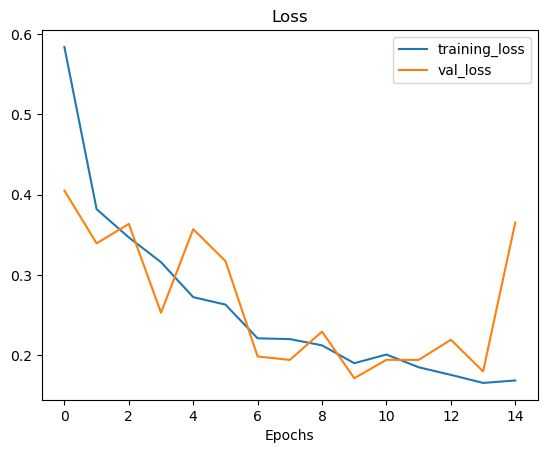

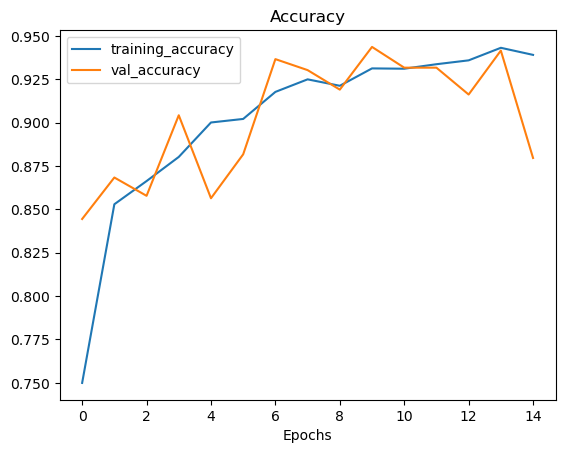

In [15]:
plot_loss_curves(history)

In conclusion, the model has an accuracy above 90% for both the training set and validation set respectively. This model has fairly good predictability.